# Stock Analysis: NVIDIA (NVDA)

This notebook analyzes NVIDIA's historical stock performance using Python.  
The analysis focuses on price trends, returns, volatility, moving averages, and risk-adjusted return.

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Investment Thesis

NVIDIA (NVDA) represents a high-growth technology company benefiting from strong demand in artificial intelligence and data center infrastructure. This analysis evaluates whether the company’s recent stock performance justifies its risk profile and supports a positive investment outlook.

Given its strong historical returns but elevated volatility and high market expectations, NVDA may offer attractive long-term potential, but requires careful evaluation of risk-adjusted performance and trend sustainability.

## 2. Data Collection

In [18]:
ticker = "NVDA"
stock = yf.Ticker(ticker)
data = stock.history(period="1y")
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-01 00:00:00-04:00,108.494426,110.174030,106.444913,110.124046,222614000,0.0,0.0
2025-04-02 00:00:00-04:00,107.264722,111.953620,106.764840,110.393982,220601200,0.0,0.0
2025-04-03 00:00:00-04:00,103.485612,105.605108,101.576059,101.776016,338769400,0.0,0.0
2025-04-04 00:00:00-04:00,98.886703,100.106409,92.088302,94.287781,532273800,0.0,0.0
2025-04-07 00:00:00-04:00,87.439395,101.726029,86.599596,97.616997,611041300,0.0,0.0


The dataset includes daily market data for NVIDIA over the past year, including open, high, low, close, trading volume, dividends, and stock splits.

## 3. Price & Risk Analysis

### Stock Price Trend

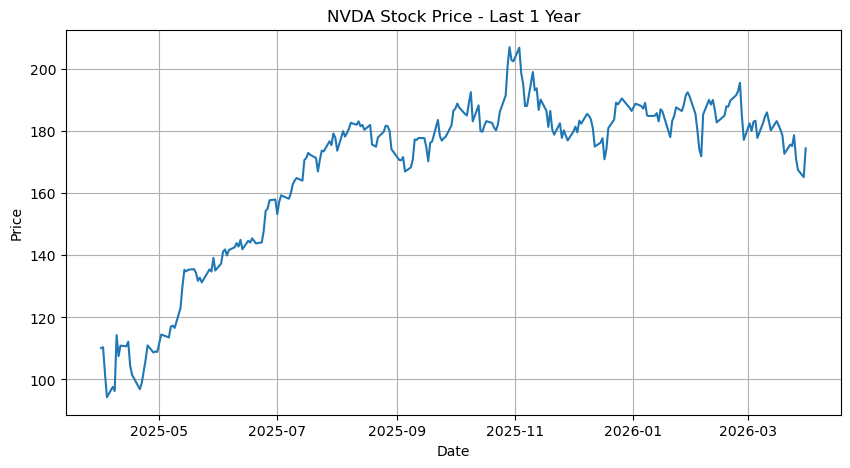

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Close"])
plt.title(f"{ticker} Stock Price - Last 1 Year")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

NVIDIA’s stock price shows a strong upward trend over much of the past year, rising significantly from its initial level before experiencing several pullbacks. The chart also shows noticeable volatility, especially in the later part of the period, suggesting that while investor sentiment has been strong, NVDA remains sensitive to broader market conditions.

### Returns Analysis

In [34]:
data["Returns"] = data[price_col].pct_change()
data = data.dropna()
data[["Returns"]].head()

,Returns
Date,
2025-04-04 00:00:00-04:00,-0.073576
2025-04-07 00:00:00-04:00,0.035309
2025-04-08 00:00:00-04:00,-0.013724
2025-04-09 00:00:00-04:00,0.187227
2025-04-10 00:00:00-04:00,-0.059127


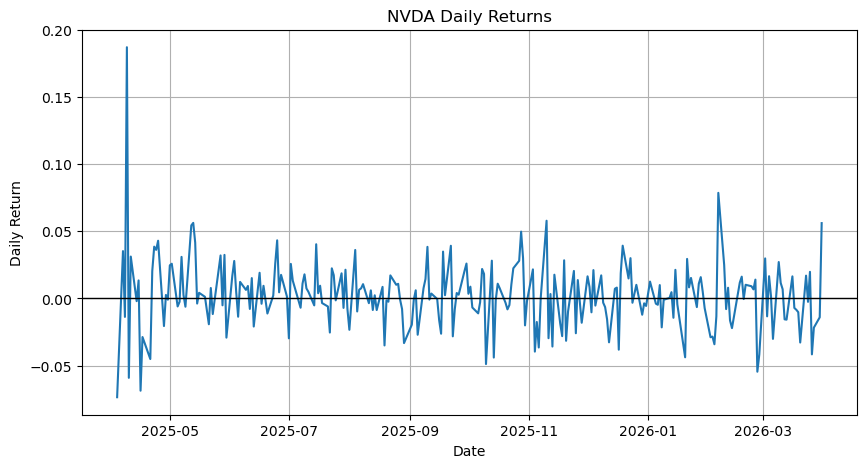

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data["Returns"])
plt.axhline(0, color = 'black', linewidth = 1)
plt.title(f"{ticker} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [27]:
mean_daily_return = data["Returns"].mean()
annualized_return = mean_daily_return * 252

print(f"Mean Daily Return: {mean_daily_return:.5f}")
print(f"Annualized Return: {annualized_return:.2%}")

Mean Daily Return: 0.00218
Annualized Return: 54.85%


Daily returns fluctuate around zero, with several large spikes indicating periods of heightened volatility. While most daily movements are relatively small, the presence of sharp positive and negative returns suggests that NVIDIA’s stock experiences occasional significant price swings.

The mean daily return is positive, leading to an annualized return of approximately 54.85%, indicating strong overall performance over the period. However, this high return should be considered alongside the observed volatility.

The variability in daily returns suggests that the stock exhibits meaningful volatility, which will be quantified in the next section.

### Volatility Analysis

In [41]:
daily_volatility = data["Returns"].std()
annualized_volatility = daily_volatility * np.sqrt(252)

print(f"Daily Volatility: {daily_volatility:.5f}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")

Daily Volatility: 0.02579
Annualized Volatility: 40.93%


NVIDIA’s daily volatility is 0.02579, which corresponds to an annualized volatility of about 40.93%. This suggests that although the stock delivered strong returns over the period, it also experienced substantial price fluctuations, meaning investors were exposed to meaningful risk alongside that performance.

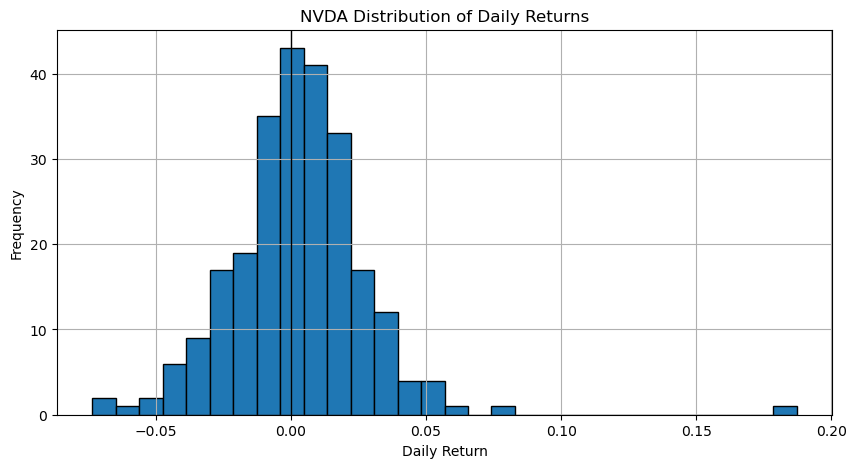

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(data["Returns"], bins=30, edgecolor="black")
plt.axvline(0, color="black", linewidth=1)
plt.title(f"{ticker} Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

The distribution of NVIDIA’s daily returns is centered near zero, indicating that most trading days involve relatively small price changes. However, the presence of longer tails and several larger positive and negative moves suggests that the stock occasionally experiences sharp swings, reinforcing the idea that it carries meaningful short-term risk and relatively high volatility.

While the stock shows strong returns, it is important to evaluate whether those returns are sufficient given the level of risk. The Sharpe Ratio provides a measure of risk-adjusted performance by comparing returns relative to volatility.

### Risk-Adjusted Performance (Sharpe Ratio)

In [46]:
risk_free_rate = 0.02 / 252
sharpe_ratio = (data["Returns"].mean() - risk_free_rate) / data["Returns"].std()
annualized_sharpe = sharpe_ratio * np.sqrt(252)

print(f"Daily Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"Annualized Sharpe Ratio: {annualized_sharpe:.2f}")

Daily Sharpe Ratio: 0.0938
Annualized Sharpe Ratio: 1.49


The Sharpe Ratio evaluates NVIDIA’s risk-adjusted performance by measuring how much return is generated for each unit of risk. With an annualized Sharpe Ratio of 1.49, the stock demonstrates solid risk-adjusted performance, indicating that its returns are reasonably well compensated for the level of volatility.

While not exceptionally high, this value suggests that NVIDIA has delivered strong returns relative to risk, making it an attractive investment from a risk-adjusted perspective over the analyzed period.

While the Sharpe Ratio evaluates NVIDIA’s risk-adjusted performance, it does not provide insight into the stock’s price trends over time. To better understand the direction and momentum of the stock, we can analyze moving averages.

### Technical Indicators (Moving Averages)

In [50]:
data["MA_20"] = data[price_col].rolling(window=20).mean()
data["MA_50"] = data[price_col].rolling(window=50).mean()

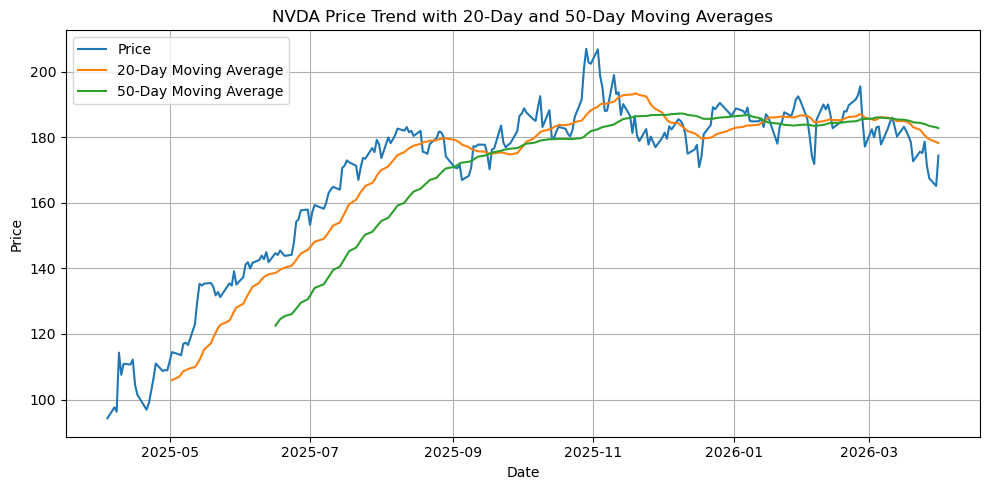

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data[price_col], label="Price")
plt.plot(data.index, data["MA_20"], label="20-Day Moving Average")
plt.plot(data.index, data["MA_50"], label="50-Day Moving Average")
plt.title(f"{ticker} Price Trend with 20-Day and 50-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The moving averages help smooth out NVIDIA’s short-term price fluctuations and make the broader trend easier to see. For much of the period, the 20-day moving average remains near or above the 50-day moving average, suggesting relatively strong momentum, although the narrowing gap and recent decline indicate that momentum has weakened toward the end of the period.

### Summary of Key Performance Metrics

In [57]:
summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Annualized Sharpe Ratio"
    ],
    "Value": [
        f"{annualized_return:.2%}",
        f"{annualized_volatility:.2%}",
        f"{annualized_sharpe:.2f}"
    ]
})

summary

,Metric,Value
0,Annualized Return,54.85%
1,Annualized Volatility,40.93%
2,Annualized Sharpe Ratio,1.49


Overall, NVIDIA delivered strong returns over the period, but with relatively high volatility. The Sharpe Ratio indicates that these returns were reasonably well compensated for the level of risk taken.

## 4. Business / Financial Overview

NVIDIA is a leading semiconductor company primarily known for designing graphics processing units (GPUs). While originally focused on gaming, the company has increasingly shifted toward data centers, artificial intelligence, and high-performance computing.

In recent years, NVIDIA’s growth has been driven largely by strong demand for AI-related infrastructure, particularly from cloud providers and enterprises investing in machine learning capabilities. This shift has positioned NVIDIA as a key player in the rapidly expanding AI industry.

However, the company also faces risks, including high valuation levels, competition from other semiconductor firms, and potential cyclicality in demand for chips. As a result, while NVIDIA benefits from strong long-term growth trends, its stock performance can be sensitive to broader market expectations and industry conditions.

## 5. Simple Valuation

NVIDIA has been one of the market’s strongest-performing growth stocks, supported by significant demand for AI and data center technologies. As a result, investors have been willing to assign the company a relatively high valuation compared to traditional semiconductor firms.

This premium valuation reflects expectations of continued strong growth, particularly in artificial intelligence and cloud computing. However, such high expectations also introduce risk, as any slowdown in growth or negative surprises could lead to significant price corrections.

Based on the strong returns observed in the analysis and the relatively high volatility, NVIDIA appears to be a high-growth, high-expectation stock. While the company’s long-term prospects remain strong, its valuation suggests that future performance is already partly priced in, making the stock more sensitive to changes in market sentiment.

## 6. Conclusion (Buy/Sell/Hold)

NVIDIA has delivered strong returns over the analyzed period, supported by significant demand for AI and data center technologies. However, this performance has been accompanied by relatively high volatility, indicating that investors have been exposed to meaningful risk.

The stock’s Sharpe Ratio of 1.49 suggests solid risk-adjusted performance, meaning that returns have been reasonably well compensated for the level of risk taken. At the same time, the recent behavior of moving averages indicates that short-term momentum may be weakening.

From a valuation perspective, NVIDIA appears to be a high-growth, high-expectation stock, with much of its future growth already reflected in its price. As a result, the stock may be more sensitive to changes in market sentiment or growth expectations.

Overall, NVIDIA represents a strong company with attractive long-term prospects, but given its high valuation and recent signs of weakening momentum, the stock is best characterized as a **Hold**. Investors may consider maintaining existing positions while waiting for more favorable entry points or clearer signals of continued growth.